In [15]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [41]:
import os
os.listdir('/kaggle/input')
os.listdir('/kaggle/input/datasets/spscientist/students-performance-in-exams')


['StudentsPerformance.csv']

In [42]:
df = pd.read_csv('/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [43]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [44]:
df.shape

(1000, 8)

In [45]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [46]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Here we can see that no columns has any missing values NA present. So we dont need to drop/fill them.

In [47]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [48]:
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

Here after replacing it is clearly visible that spaces are replaced by underscore (eg math_score)

In [49]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [50]:
df['parental_level_of_education'] = df['parental_level_of_education'].str.lower()

In [53]:
df['lunch'] = df['lunch'].str.lower()

In [54]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

In [55]:
top_10students = df.sort_values(by='total_score', ascending=False).head(10)
print(top_10students)

     gender race/ethnicity parental_level_of_education         lunch  \
916    male        group E           bachelor's degree      standard   
962  female        group E          associate's degree      standard   
458  female        group E           bachelor's degree      standard   
114  female        group E           bachelor's degree      standard   
712  female        group D                some college      standard   
179  female        group D            some high school      standard   
165  female        group C           bachelor's degree      standard   
625    male        group D                some college      standard   
685  female        group E             master's degree      standard   
903  female        group D           bachelor's degree  free/reduced   

    test_preparation_course  math_score  reading_score  writing_score  \
916               completed         100            100            100   
962                    none         100            100       

In [56]:
df.groupby('gender')[['math_score','reading_score','writing_score']].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


OBESERVATIONS:
1) Females have a higher average score in reading and writing whereas males have a higher average score in math
2) 3 students were able to score an out of score 300/300 in all 3 subjects
3) In the tope 10, 8 out of the 10 (80%) of the students are females
4) 90% of students in the top 10 have standard lunch type

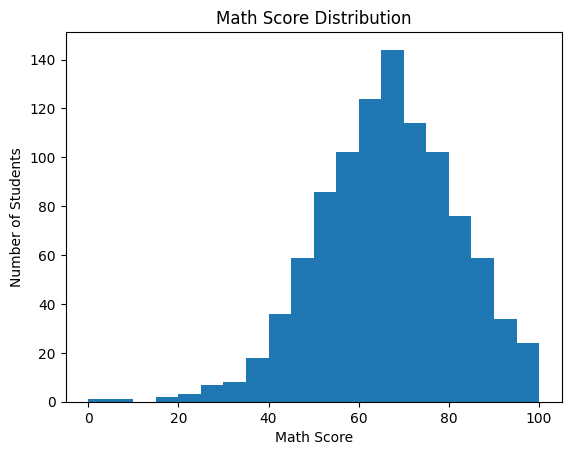

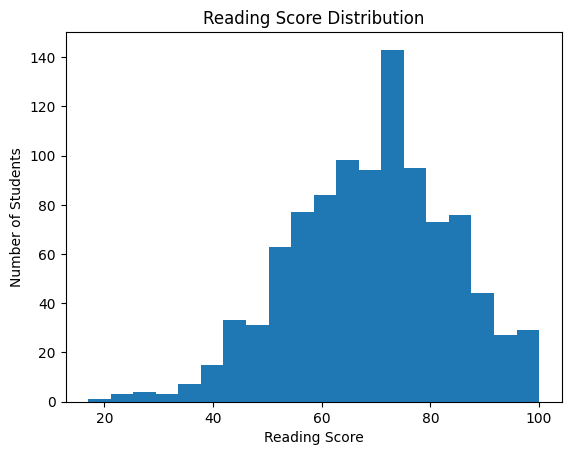

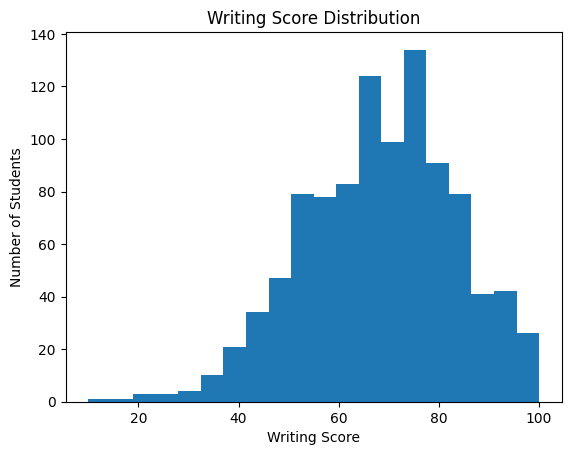

In [57]:
plt.figure()
plt.hist(df['math_score'], bins=20)
plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.show()

plt.figure()
plt.hist(df['reading_score'], bins=20)
plt.title('Reading Score Distribution')
plt.xlabel('Reading Score')
plt.ylabel('Number of Students')
plt.show()

plt.figure()
plt.hist(df['writing_score'], bins=20)
plt.title('Writing Score Distribution')
plt.xlabel('Writing Score')
plt.ylabel('Number of Students')
plt.show()

Q1)Are scores normally distributed?
No the scores are not normally distributed with heavy frequency in the 60-100 range
Q2) Which group performs better?
The Math group has performed the best

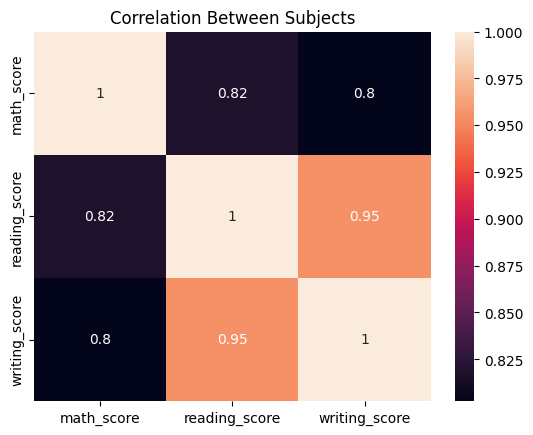

In [59]:
sns.heatmap(df[['math_score','reading_score','writing_score']].corr(), annot=True)

plt.title('Correlation Between Subjects')
plt.show()

Q3) Are subjects correlated?
Yes the corelation map shows that all the 3 subjects are highly corelated. This means that the probability of students performing well in all 3 subjects id extremely high.

In [63]:
df['total_score'] = df['math_score']+df['reading_score'] + df['writing_score']

The total_score maps the sum of all the scores in math, reading and writing. This could be of great importance in Machine Learning as it would help models track the overall growth of the student.

In [66]:
df['test_preparation_course'].head()

0    0
1    1
2    0
3    0
4    0
Name: test_preparation_course, dtype: int64

In [67]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score'],
      dtype='object')


Here the categorical columns are encoded, numeric columns are present and dataset is already cleaned

ML models cannot understand normal text so the categories have to converted into numbers.Here the test_preparation_course column was encoded using the binary mapping process ie completed:1,none:0

In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['math_score','reading_score','writing_score','total_score']] = scaler.fit_transform(
    df[['math_score','reading_score','writing_score','total_score']]
)

Here we used MinMaxScaler to add numerical features. Scaling ensures numeric features have similar ranges so that no single feature dominates the learning process of the machine learning model. Due to this scaling we can ensure each feature falls in the range of 0 and 1 and th scale of the input features are kept in check.

In [70]:
df.to_csv("processed.csv", index=False)

In [71]:
pd.read_csv('processed.csv').head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,0,0.72,0.662651,0.711111,0.699634
1,female,group C,some college,standard,1,0.69,0.879518,0.866667,0.805861
2,female,group B,master's degree,standard,0,0.90,0.939759,0.922222,0.919414
3,male,group A,associate's degree,free/reduced,0,0.47,0.481928,0.377778,0.443223
4,male,group C,some college,standard,0,0.76,0.734940,0.722222,0.739927
